# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [ ]:
!pip install lime

### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [ ]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답: LIME(Local Interpretable Model-agnostic Explanations)은 복잡한 모델의 예측 결과를 설명할 수 있는 간단한 선형 모델을 찾아서(fit) 국소적인 설명이 가능하도록 하는 방식을 아이디어로 동작한다.<br>
더 구체적으로는 특정 데이터(A)에 대하여 왜 그런 결과가 나오게 되었는지를 설명할 수 있다. 이를 위해서 LIME은 해석하고자 하는 데이터를 중심으로 이 주변이라고 할 수 있는 변형된 데이터 샘플(A')들을 생성한다. 이후 생성한 데이터 샘플(A')들과 실제 원본 데이터 간의 거리를 기반으로 가중치를 부여하고, 데이터 샘플(A')들을 원래의 모델을 통해 추론(Inference)을 진행한다. 그 결과에 해당하는 예측 점수를 통해서 특정 데이터(A)에 대한 선형 회귀 모델을 학습하여 원본 데이터가 가진 특징의 기여도를 추출하는 방식으로 동작한다.

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답: Surrogate Model은 LIME에서 복잡한 원래 모델(Black-box)의 국소적인 특징을 학습한 간단한 선형 회귀 혹은 결정 트리 모델을 의미한다. 즉, 개별 예측을 설명하는 데에 사용할 수 있는 해석용 모델이다.<br>
Surrogate Model은 변형된 데이터 샘플을 사용해서 시뮬레이션 결과적으로 특정 특성이 구체적으로 결과에 얼마나 기여할 수 있는지를 통해 해결할 수 있다. LIME는 복잡성을 단순하게 표현할 수 있고, 설명하고자 하는 데이터에 대한 구체적인 설명을 제시할 수 있다. 또 입력과 출력에 대한 구체적인 관계를 나타낼 수 있다.

---

#2. SHAP

In [ ]:
!pip install shap

### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


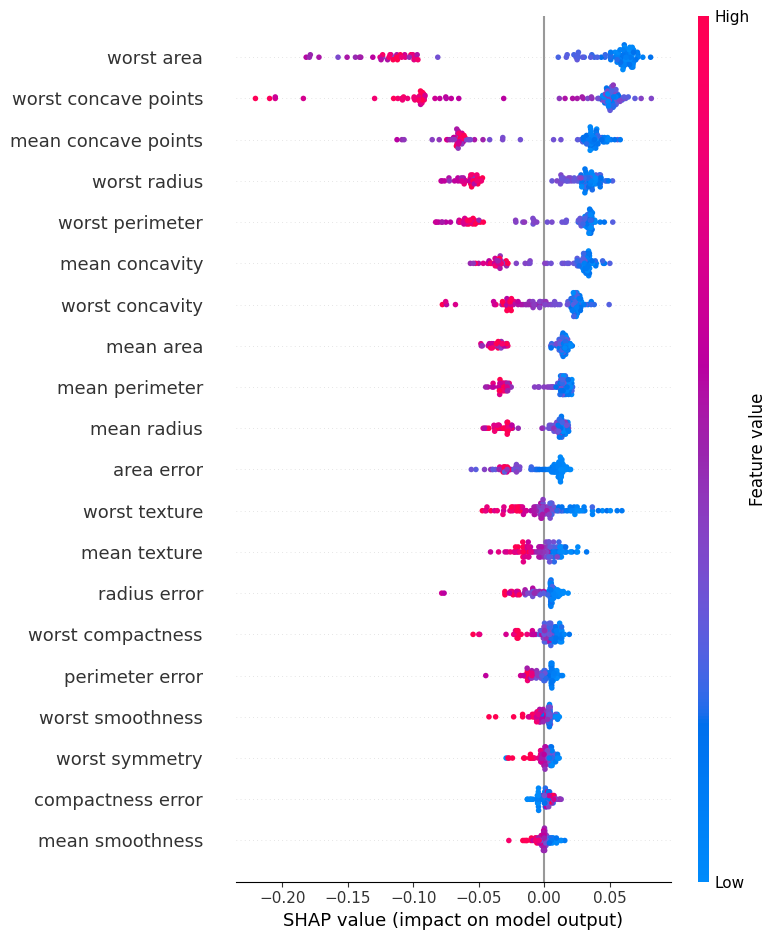

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답: SHAP Value는 각 특성이 모델의 예측 결과에 미친 기여도를 계산한 결과이다. 따라서 SHAP Value가 양수라면, 해당 특성이 모델의 최종 예측값을 높이는 방향으로 작용했다는 의미이고, 음수라면 해당 특성이 모델의 최종 예측을 낮추는 방향으로 작용했다는 것을 의미한다. 이에 더하여 만일 0에 근접하다면 해당 특성은 예측 결과와 영향이 없음을 의미한다.<br>
위의 결과로 봤을 때, worst area라는 특성은 모델의 최종 예측값을 낮추는 데에도 큰 기여를 했고, 높이는 데에도 다른 특성에 비하여 큰 기여를 했다고 해석할 수 있다.

Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답: Tree의 entropy와 geni index 기반의 feature importance는 트리가 노드를 분할할 때의 불순도를 계산하는 역할을 한다. 이 경우에는 해당 변수가 데이터를 분할하는 데에 얼마나 효율적이었는 지에 대한 계산 결과이다. 이 값은 모델 전체의 학습 과정에 대하여 트리 분할 시의 효율성에 대한 값이기 때문에 각 feature의 중요도를 설명하고자 하는 SHAP의 feature importance와는 다른 특성이라고 이해할 수 있다. 또한, 이 값은 해당 특성에 대한 상관관계를 파악할 수 없고, 변수들 간의 상호작용에 대한 설명도 어려울 수 있다.<br>
반면 SHAP의 feature importance는 각각의 개별 데이터에 대하여 해당 특성의 기여도가 계산되기 때문에 해당 특성이 예측값의 변화에 기여한 평균을 계산할 수 있다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

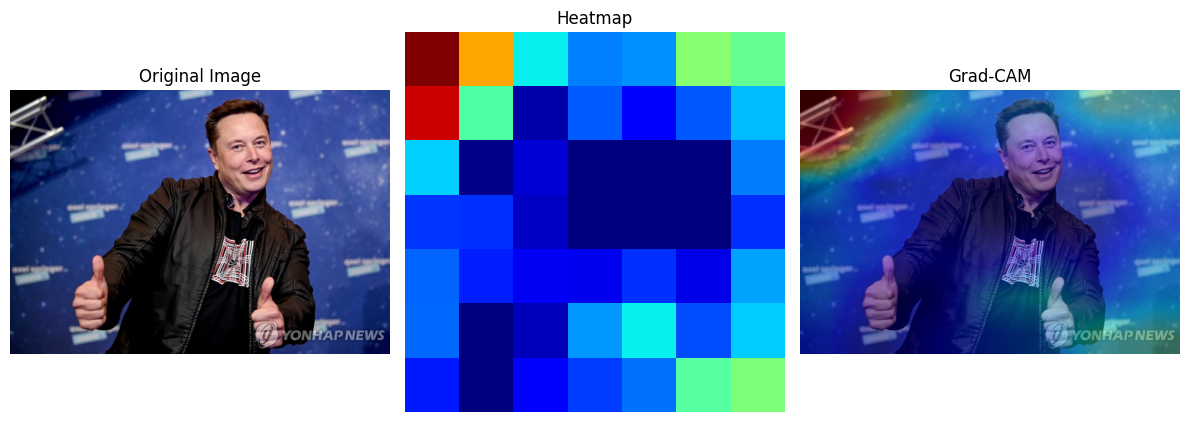

예측된 클래스 인덱스: 819


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

print(f"예측된 클래스 인덱스: {pred_index}")

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답: Grad-CAM이 기존 CAM과 유사하게 마지막 컨볼루션 층을 사용하는 이유는 마지막 convolution layer가 가장 높은 수준으로 추상화된 정보(high-level semantics)와 구체적인 공간 정보(detailed spatial information)를 가지고 있기 때문이다. 마지막 컨볼루션 층은 출력 층에 해당하는 softmax로 가기 전의 마지막 층이기 때문에 클래스 정보 결과와 feature map간의 인과관계를 직접적으로 확인할 수 있다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답: 우선 붉거나 파랗게 표시되는 등의 각 영역(원소)은 해당 원소가 특정 class에 주는 영향력(gradient)에 해당된다. 더 구체적으로는 gradient에 의해서 계산된 alpha value가 표현된 결과이다.<br>
이 결과가 붉다는 것은 특정 클래스의 예측 점수를 해당 레이어의 feature map으로 미분해서 구한 가중치가 큰 곳임을 의미한다. 즉, 해당 원소가 특정 클래스일 확률을 높이는 데에 많이 기여했다는 의미이다. 따라서 Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델이 특정 클래스임을 판단하는 데에 크게 기여한다.

In [ ]:
# ImageNet 클래스 레이블
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(LABELS_URL).text.splitlines()

# 예측 결과 출력
predicted_label = labels[pred_index]
print(f"최종 예측 결과: {predicted_label} (Index: {pred_index})")

최종 예측 결과: stage (Index: 819)


Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답: Grad-CAM은 현재 ImageNet 클래스를 기반으로 클래스를 예측하고, 해당 클래스 예측에 기여도가 큰 부분을 붉은 색으로 표시하고 있다. 현재 코드를 통해 예측된 결과는 우리가 생각했을 때의 중요한 객체로 여겨지는 일론머스크(사람)이 아니라, Index 819번에 해당하는 stage를 예측했다. ImageNet 데이터셋에는 사람의 얼굴임을 인식하는 label이 없다. 따라서 Grad-CAM 으로 시각화 한 heatmap이 이미지의 중요한 객체를 인식한 것이 아니라 클래스 예측에 사용되는 819번 부근을 담고 있다고 생각한다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [ ]:
# 이미지 로드 및 전처리
# url = 'https://blog.kakaocdn.net/dna/cyD9pn/btsOxFfpiiW/AAAAAAAAAAAAAAAAAAAAAFGiOvHL_qlCUiUiUIg1JagJFnkaarNn8GiOBCO__hEp/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1774969199&allow_ip=&allow_referer=&signature=yWd4YCmf%2B1q9tAkMCHkW0O6PyJQ%3D'
## 이미지 로드 상의 오류로, 위의 코드에서 사용했던 다른 이미지로 대체
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

In [ ]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [ ]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [ ]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [ ]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [ ]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

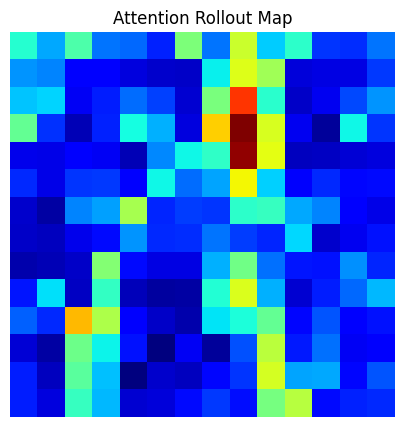

In [ ]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



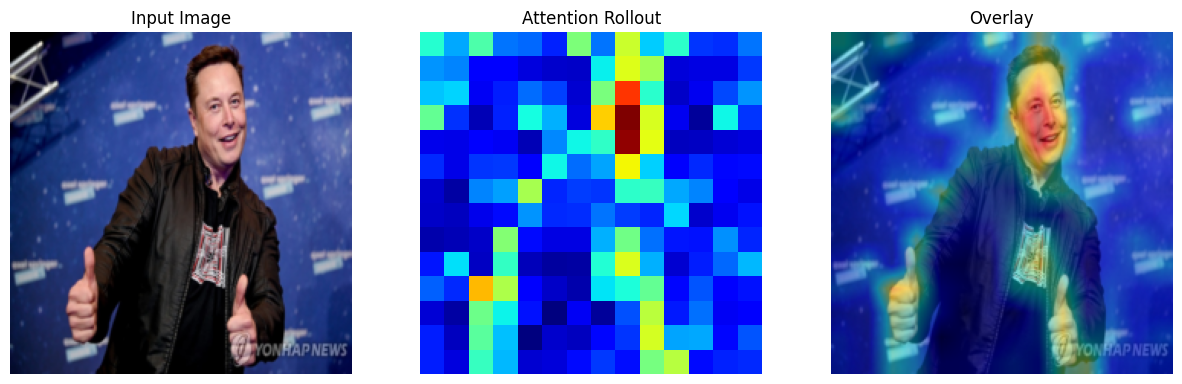

In [ ]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답: Attention rollout 방법은 기존에 한 층에 대해서만 관계를 파악하던 단순한 Attention Score 알고리즘 대신 계층 간의 정보도 고려할 수 있도록 Attention 결과를 누적 계산한다. 또한, 잔차 연결을 통해서 이전 층으로부터 전달된 정보를 파악하고, 단순히 Score 기반이 아니라 각 층의 상호작용을 반영할 수 있는 Attention 값을 통해서 실질적으로 결과 도출에 기여한 토큰을 확인할 수 있기 때문이다. 따라서 이를 기반으로 기존의 Attention Score 보다 더 높은 신뢰도로 더 정확히 기여도를 확인할 수 있다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답: LIME을 위한 가상의 데이터를 생성할 때, 증강한 데이터의 전체를 무작위로 많은 다수의 데이터를 생성하는 것이 아니라 데이터의 일부는 Score가 높은 토큰 주변의 토큰을 위주로 변형하는 방식으로 데이터를 생성해서 사용한다면, 더 빠르고 의미있는 surrogate model 학습에 기여할 수 있을 것이라고 생각한다.